# Module 2 Pilot Research: Latent Political Attitudes in Fine-Tuned LLMs

**Research Question:** Can politically distinct language patterns be detected in LLMs fine-tuned separately on TikTok video descriptions reposted by inferred Democrats (followers of @kamalahq) vs. inferred Republicans (followers of @teamtrump)?

**Approach (following Module 2 LoRA fine-tuning guide):**
1. Load and partition TikTok corpus by political affiliation label
2. Fine-tune GPT-2 with LoRA on each partition separately
3. Compare trainable parameters (LoRA vs. full fine-tuning)
4. Experiment with LoRA rank values (r=4, 8, 16) — Module 2 Task 3
5. Probe both fine-tuned models with politically charged prompts to surface latent attitudes
6. Measure perplexity and representational divergence (CKA) between the two models

**Dataset:** `tiktok_breadth_first.db` — TikTok video descriptions joined to follow-relations
- `kamalahq` followers → inferred **Democrat** corpus
- `teamtrump` followers → inferred **Republican** corpus


## Step 0: Install & Import Libraries

Following Module 2 setup — we install `transformers`, `peft`, `accelerate`, and `bitsandbytes`.

In [1]:
# Install required packages (run once in Colab)
!pip install transformers accelerate datasets bitsandbytes peft -q

import sqlite3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time, os
from collections import defaultdict

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model, TaskType
from torch.utils.data import Dataset

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
Device: cuda
PyTorch: 2.10.0+cu128
CUDA available: True


## Step 1: Load & Partition the TikTok Corpus

We query the SQLite database used in Module 1 sampling exercises, splitting video descriptions by inferred political affiliation.

- **Democrat corpus**: videos reposted by followers of @kamalahq
- **Republican corpus**: videos reposted by followers of @teamtrump

We balance the two corpora (equal N) to avoid the imbalanced-class problems explored in Module 1.


In [2]:
# ── Connect to the TikTok database ────────────────────────────────────────────
from google.colab import drive
import gdown

drive.mount('/content/drive')

db_path = '/content/drive/MyDrive/colabshortcuts/tiktok_breadth_first.db'

conn = sqlite3.connect(db_path)

query = """
SELECT video_description, fr.to_username
FROM videos
JOIN follow_relations AS fr
  ON videos.reposter_username = fr.from_username
WHERE fr.to_username = 'kamalahq'
  AND video_description IS NOT NULL
  AND length(trim(video_description)) > 16
ORDER BY RANDOM()
LIMIT 100000
"""

k_df = pd.read_sql_query(query, conn)

query = """
SELECT video_description, fr.to_username
FROM videos
JOIN follow_relations AS fr
  ON videos.reposter_username = fr.from_username
WHERE fr.to_username = 'teamtrump'
  AND video_description IS NOT NULL
  AND length(trim(video_description)) > 16
ORDER BY RANDOM()
LIMIT 100000
"""

t_df = pd.read_sql_query(query, conn)
conn.close()

df = pd.concat([k_df, t_df])

print(f"Total rows fetched: {len(df):,}")
print("\nLabel distribution (raw):")
print(df['to_username'].value_counts())


Mounted at /content/drive
Total rows fetched: 200,000

Label distribution (raw):
to_username
kamalahq     100000
teamtrump    100000
Name: count, dtype: int64


In [3]:
# ── Balance the two corpora ────────────────────────────────────────────────────
# Following Module 1 best practice: equal sample sizes remove class-imbalance bias

SAMPLE_SIZE = 15000  # per group — large enough for meaningful fine-tuning, small enough to run in Colab

df_dem = df[df['to_username'] == 'kamalahq'].sample(
    n=min(SAMPLE_SIZE, (df['to_username'] == 'kamalahq').sum()),
    random_state=42
).reset_index(drop=True)

df_rep = df[df['to_username'] == 'teamtrump'].sample(
    n=min(SAMPLE_SIZE, (df['to_username'] == 'teamtrump').sum()),
    random_state=42
).reset_index(drop=True)

print(f"Democrat corpus  : {len(df_dem):,} texts")
print(f"Republican corpus: {len(df_rep):,} texts")
print("\nSample Democrat descriptions:")
for t in df_dem['video_description'].head(3):
    print(f"  · {t[:100]}")
print("\nSample Republican descriptions:")
for t in df_rep['video_description'].head(3):
    print(f"  · {t[:100]}")


Democrat corpus  : 15,000 texts
Republican corpus: 15,000 texts

Sample Democrat descriptions:
  · Im in Opium baby take me back and ill let u meet Carti #fyp #foryou 
  · MOOD BC IM SEEING TAME IMPLALA NEXT YEAR WITH TWIN <3 @Steyn.  effects:mine/ @blohsh_ae  cc:@𝙢𝙦𝙫𝙞𝙨𝙨 
  · [#FNAF] mim -owner 1 ||tags;;#fyp#gacha#aftonpoopoo

Sample Republican descriptions:
  · #love #relateable #relationship #fyp #viral 
  · C’est toujours de l’humour #pourtoi #humour #cheveuxbleu 
  · he obviously didnt but i thought it was funny 🫩 #fortnite #spongebobsquarepants #fortnitefunny #fyp 


## Step 2: Tokenise the Corpora

We use GPT-2 (small, 124M parameters) as our base model — consistent with Module 2's recommendation to use a small LLM for tractable fine-tuning experiments. GPT-2 is well-suited to short social media texts.


In [4]:
# ── Load tokenizer ────────────────────────────────────────────────────────────
MODEL_NAME = "gpt2"   # 124M params

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

MAX_LENGTH = 256

# ── Custom Dataset class ───────────────────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=64):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
    def __len__(self):
        return self.encodings['input_ids'].shape[0]
    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.encodings['input_ids'][idx].clone(),
        }

# Train/val split (90/10)
def split_texts(df_group, val_frac=0.1, random_state=42):
    texts = df_group['video_description'].tolist()
    np.random.seed(random_state)
    idx = np.random.permutation(len(texts))
    split = int(len(texts) * (1 - val_frac))
    return [texts[i] for i in idx[:split]], [texts[i] for i in idx[split:]]

dem_train_texts, dem_val_texts = split_texts(df_dem)
rep_train_texts, rep_val_texts = split_texts(df_rep)

dem_train_ds = TextDataset(dem_train_texts, tokenizer, MAX_LENGTH)
dem_val_ds   = TextDataset(dem_val_texts,   tokenizer, MAX_LENGTH)
rep_train_ds = TextDataset(rep_train_texts, tokenizer, MAX_LENGTH)
rep_val_ds   = TextDataset(rep_val_texts,   tokenizer, MAX_LENGTH)

print(f"Democrat  — train: {len(dem_train_ds):,} | val: {len(dem_val_ds):,}")
print(f"Republican — train: {len(rep_train_ds):,} | val: {len(rep_val_ds):,}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Democrat  — train: 13,500 | val: 1,500
Republican — train: 13,500 | val: 1,500


## Step 3: Compare Trainable Parameters — Full Fine-Tuning vs. LoRA

**Module 2 Task 2**: Demonstrate the parameter efficiency of LoRA relative to full fine-tuning.

LoRA freezes the pre-trained weights and injects trainable low-rank matrices (rank *r*) into the attention projection layers. This dramatically reduces the number of updated parameters.


In [5]:
# ── Load base model ───────────────────────────────────────────────────────────
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,   # float32 for CPU-safe training
)
base_model.resize_token_embeddings(len(tokenizer))

total_params = sum(p.numel() for p in base_model.parameters())
print(f"GPT-2 total parameters: {total_params:,}")
print(f"  ≈ {total_params/1e6:.1f}M parameters\n")

# ── Apply LoRA (r=8, following Module 2 example) ─────────────────────────────
lora_config_r8 = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["c_attn"],   # GPT-2 uses c_attn for Q,K,V projections
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model_lora = get_peft_model(base_model, lora_config_r8)

trainable_params = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)
print(f"LoRA trainable parameters (r=8): {trainable_params:,}")
print(f"LoRA trainable / total: {trainable_params/total_params*100:.2f}%")
print(f"Parameter reduction factor: {total_params/trainable_params:.0f}x")
model_lora.print_trainable_parameters()


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 total parameters: 124,439,808
  ≈ 124.4M parameters

LoRA trainable parameters (r=8): 294,912
LoRA trainable / total: 0.24%
Parameter reduction factor: 422x
trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## Step 4: LoRA Rank Experiment (r = 4, 8, 16)

**Module 2 Task 3**: Experiment with different LoRA rank values and observe the impact on the number of trainable parameters and validation perplexity.

Higher rank *r* means more expressive adapters but more parameters. For our pilot, we run each rank on a small subset of the Democrat corpus to compare quickly.


In [6]:
# ── Count trainable parameters across ranks ──────────────────────────────────
rank_results = {}

for r in [4, 8, 16]:
    # Fresh copy of base model
    m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)
    m.resize_token_embeddings(len(tokenizer))
    cfg = LoraConfig(
        r=r, lora_alpha=32,
        target_modules=["c_attn"],
        lora_dropout=0.05, bias="none",
        task_type=TaskType.CAUSAL_LM
    )
    m_lora = get_peft_model(m, cfg)
    tp = sum(p.numel() for p in m_lora.parameters() if p.requires_grad)
    rank_results[r] = {'trainable_params': tp}
    print(f"r={r:2d} | Trainable params: {tp:,}  ({tp/total_params*100:.2f}% of base model)")
    del m, m_lora

# ── Mini perplexity comparison across ranks ────────────────────────────────────
# Use a small subset for fast experimentation (500 train, 200 val)
MINI_TRAIN = 500
MINI_VAL   = 200

mini_train_ds = TextDataset(dem_train_texts[:MINI_TRAIN], tokenizer, MAX_LENGTH)
mini_val_ds   = TextDataset(dem_val_texts[:MINI_VAL],   tokenizer, MAX_LENGTH)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

for r in [4, 8, 16]:
    print(f"\n--- Training LoRA r={r} (mini subset, 1 epoch) ---")
    m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)
    m.resize_token_embeddings(len(tokenizer))
    cfg = LoraConfig(
        r=r, lora_alpha=32,
        target_modules=["c_attn"],
        lora_dropout=0.05, bias="none",
        task_type=TaskType.CAUSAL_LM
    )
    m_lora = get_peft_model(m, cfg)

    train_args = TrainingArguments(
        output_dir=f"/tmp/lora_r{r}",
        num_train_epochs=1,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-4,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=False,  # safe on CPU; set True on GPU
        report_to="none",
        max_grad_norm=1.0,
    )
    trainer = Trainer(
        model=m_lora,
        args=train_args,
        train_dataset=mini_train_ds,
        eval_dataset=mini_val_ds,
        data_collator=data_collator,
    )
    trainer.train()
    eval_res = trainer.evaluate()
    ppl = np.exp(eval_res['eval_loss'])
    rank_results[r]['val_perplexity'] = ppl
    print(f"  r={r} → val_loss={eval_res['eval_loss']:.4f}, perplexity={ppl:.2f}")
    del m, m_lora, trainer

print("\n=== Rank Summary ===")
for r, res in rank_results.items():
    print(f"r={r:2d} | Trainable: {res['trainable_params']:,} | PPL: {res.get('val_perplexity', 'N/A'):.2f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


r= 4 | Trainable params: 147,456  (0.12% of base model)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  r=8 → val_loss=4.4423, perplexity=84.97

--- Training LoRA r=16 (mini subset, 1 epoch) ---


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,5.072830,4.435306


  r=16 → val_loss=4.4353, perplexity=84.38

=== Rank Summary ===
r= 4 | Trainable: 147,456 | PPL: 85.43
r= 8 | Trainable: 294,912 | PPL: 84.97
r=16 | Trainable: 589,824 | PPL: 84.38


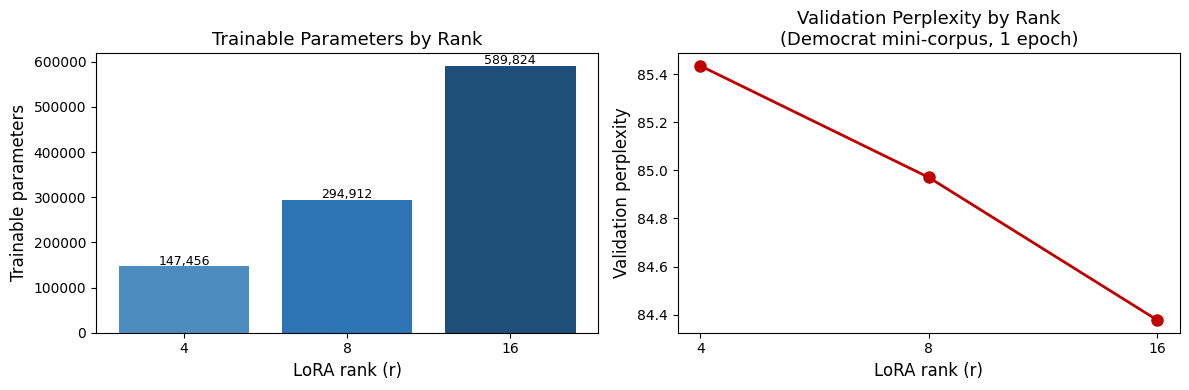

Saved: /tmp/rank_experiment.png


In [7]:
# ── Visualise rank experiment ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ranks = list(rank_results.keys())
params = [rank_results[r]['trainable_params'] for r in ranks]
ppls   = [rank_results[r].get('val_perplexity', np.nan) for r in ranks]

axes[0].bar([str(r) for r in ranks], params, color=['#4C8CBF','#2E75B6','#1F4E79'])
axes[0].set_xlabel("LoRA rank (r)", fontsize=12)
axes[0].set_ylabel("Trainable parameters", fontsize=12)
axes[0].set_title("Trainable Parameters by Rank", fontsize=13)
for i,(x,y) in enumerate(zip(ranks, params)):
    axes[0].text(i, y*1.01, f"{y:,}", ha='center', fontsize=9)

axes[1].plot([str(r) for r in ranks], ppls, marker='o', color='#C00000', linewidth=2, markersize=8)
axes[1].set_xlabel("LoRA rank (r)", fontsize=12)
axes[1].set_ylabel("Validation perplexity", fontsize=12)
axes[1].set_title("Validation Perplexity by Rank\n(Democrat mini-corpus, 1 epoch)", fontsize=13)

plt.tight_layout()
plt.savefig("/tmp/rank_experiment.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: /tmp/rank_experiment.png")


## Step 5: Fine-Tune Two Partisan LLMs

Following Module 2 Task 1 — we fine-tune GPT-2 with LoRA (r=8) once on the Democrat corpus and once on the Republican corpus. The two resulting models encode the distinct linguistic patterns of each political group.

**Hypothesis**: If latent political attitudes are present in the text distributions, the fine-tuned models will diverge in:
- Validation perplexity on cross-partisan text
- Token probability distributions on politically charged prompts


In [8]:
# ── Helper: build a fresh LoRA model ─────────────────────────────────────────
def make_lora_model(rank=8):
    m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
    m.resize_token_embeddings(len(tokenizer))
    cfg = LoraConfig(
        r=rank, lora_alpha=32,
        target_modules=["c_attn"],
        lora_dropout=0.05, bias="none",
        task_type=TaskType.CAUSAL_LM
    )
    return get_peft_model(m, cfg)

# ── Helper: training arguments ────────────────────────────────────────────────
def make_training_args(output_dir, epochs=2):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-4,
        warmup_steps=50,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=False,   # Change to True on GPU
        report_to="none",
        max_grad_norm=1.0,
    )

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
print("Helper functions ready.")

Helper functions ready.


In [9]:
# ════════════════════════════════════════════════════════════════════
# Fine-tune Model A: Democrat (kamalahq followers)
# ════════════════════════════════════════════════════════════════════
print("=== Training DEMOCRAT model (LoRA r=8, 2 epochs) ===\n")

model_dem = make_lora_model(rank=8)
trainer_dem = Trainer(
    model=model_dem,
    args=make_training_args("/tmp/dem_lora", epochs=2),
    train_dataset=dem_train_ds,
    eval_dataset=dem_val_ds,
    data_collator=data_collator,
)
t0 = time.time()
trainer_dem.train()
dem_train_time = time.time() - t0

eval_dem_on_dem = trainer_dem.evaluate()
dem_ppl = np.exp(eval_dem_on_dem['eval_loss'])
print(f"\nDemocrat model — val perplexity (own corpus): {dem_ppl:.2f}")
print(f"Training time: {dem_train_time/60:.1f} min")

=== Training DEMOCRAT model (LoRA r=8, 2 epochs) ===



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,4.079709,3.879458
2,3.970091,3.834285



Democrat model — val perplexity (own corpus): 46.26
Training time: 25.6 min


In [10]:
# ════════════════════════════════════════════════════════════════════
# Fine-tune Model B: Republican (teamtrump followers)
# ════════════════════════════════════════════════════════════════════
print("=== Training REPUBLICAN model (LoRA r=8, 2 epochs) ===\n")

model_rep = make_lora_model(rank=8)
trainer_rep = Trainer(
    model=model_rep,
    args=make_training_args("/tmp/rep_lora", epochs=2),
    train_dataset=rep_train_ds,
    eval_dataset=rep_val_ds,
    data_collator=data_collator,
)
t0 = time.time()
trainer_rep.train()
rep_train_time = time.time() - t0

eval_rep_on_rep = trainer_rep.evaluate()
rep_ppl = np.exp(eval_rep_on_rep['eval_loss'])
print(f"\nRepublican model — val perplexity (own corpus): {rep_ppl:.2f}")
print(f"Training time: {rep_train_time/60:.1f} min")


=== Training REPUBLICAN model (LoRA r=8, 2 epochs) ===



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,4.031006,3.857898
2,3.999523,3.815405



Republican model — val perplexity (own corpus): 45.40
Training time: 25.5 min


## Step 6: Cross-Partisan Perplexity

If the two models have learned distinct linguistic distributions, each should assign **higher perplexity** to the opposing group's text. This is a quantitative test of political linguistic distinctiveness.

| | Evaluated on Democrat text | Evaluated on Republican text |
|---|---|---|
| Democrat model | *(in-distribution)* | *(cross-partisan)* |
| Republican model | *(cross-partisan)* | *(in-distribution)* |


In [11]:
# ── Evaluate Democrat model on Republican validation texts ──────────────────
# Create TrainingArguments specifically for evaluation, disabling internal evaluation during Trainer init
eval_args = TrainingArguments(
    output_dir="/tmp/tmp_eval",
    per_device_eval_batch_size=16, # Keep batch size consistent
    eval_strategy="no",            # Crucial: disable internal evaluation during Trainer initialization
    report_to="none",              # No reporting needed for simple evaluation
)

trainer_dem_eval = Trainer(
    model=model_dem,
    args=eval_args,
    data_collator=data_collator,
)
eval_dem_on_rep = trainer_dem_eval.evaluate(eval_dataset=rep_val_ds)
dem_on_rep_ppl = np.exp(eval_dem_on_rep['eval_loss'])

# ── Evaluate Republican model on Democrat validation texts ───────────────────
trainer_rep_eval = Trainer(
    model=model_rep,
    args=eval_args, # Reuse the same evaluation arguments
    data_collator=data_collator,
)
eval_rep_on_dem = trainer_rep_eval.evaluate(eval_dataset=dem_val_ds)
rep_on_dem_ppl = np.exp(eval_rep_on_dem['eval_loss'])

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"{'':20s} {'Dem text':>15} {'Rep text':>15}")
print("-" * 55)
print(f"{'Democrat model':20s} {dem_ppl:>15.2f} {dem_on_rep_ppl:>15.2f}")
print(f"{'Republican model':20s} {rep_on_dem_ppl:>15.2f} {rep_ppl:>15.2f}")
print("=" * 55)
print("\nInterpretation: higher cross-partisan perplexity = greater linguistic divergence")

                            Dem text        Rep text
-------------------------------------------------------
Democrat model                 46.26           47.45
Republican model               49.13           45.40

Interpretation: higher cross-partisan perplexity = greater linguistic divergence


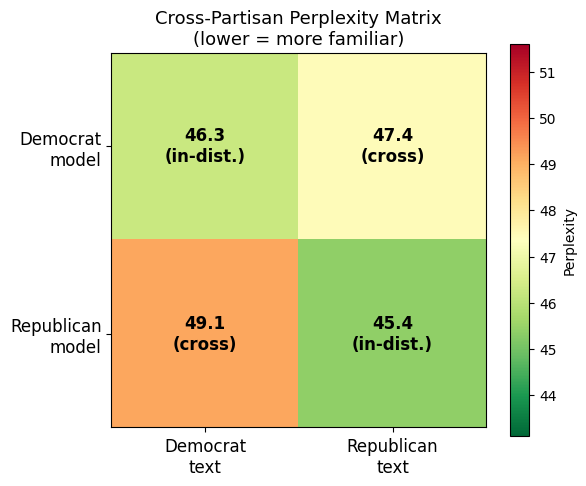

In [12]:
# ── Perplexity heatmap ────────────────────────────────────────────────────────
ppl_matrix = np.array([[dem_ppl, dem_on_rep_ppl],
                        [rep_on_dem_ppl, rep_ppl]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ppl_matrix, cmap='RdYlGn_r', vmin=ppl_matrix.min()*0.95,
               vmax=ppl_matrix.max()*1.05)
plt.colorbar(im, ax=ax, label='Perplexity')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Democrat\ntext', 'Republican\ntext'], fontsize=12)
ax.set_yticklabels(['Democrat\nmodel', 'Republican\nmodel'], fontsize=12)
ax.set_title('Cross-Partisan Perplexity Matrix\n(lower = more familiar)', fontsize=13)

for i in range(2):
    for j in range(2):
        label = 'in-dist.' if i == j else 'cross'
        ax.text(j, i, f"{ppl_matrix[i,j]:.1f}\n({label})",
                ha='center', va='center', fontsize=12, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig("/tmp/perplexity_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()


## Step 7: Prompt Probing — Surfacing Latent Political Attitudes

To directly test whether political attitudes are encoded in each model, we generate text completions from politically relevant prompts and compare them. This is analogous to value probing studies in alignment research.

We look at both:
1. **Generated text** — qualitative examination of completions
2. **Log-probability differences** — quantitative divergence on politically charged token continuations


In [13]:
# ── Text generation helper ────────────────────────────────────────────────────
def generate_completion(model, prompt, max_new_tokens=60, num_return=3):
    """Generate text completions from a prompt using the given model."""
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt")
    input_ids = inputs["input_ids"].to(model.device) # Move input_ids to the same device as the model

    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            num_return_sequences=num_return,
            do_sample=True,
            temperature=0.9,
            top_p=0.92,
            repetition_penalty=1.3,
            pad_token_id=tokenizer.eos_token_id,
        )
    completions = []
    for out in outputs:
        text = tokenizer.decode(out[input_ids.shape[-1]:], skip_special_tokens=True)
        completions.append(text.strip())
    return completions

# ── Politically charged prompts ────────────────────────────────────────────────
PROBES = [
    "The government should",
    "Healthcare in America is",
    "Immigration is",
    "The election was",
    "Climate change is",
    "Police in America",
    "The border",
    "Taxes should",
]

print("Probe prompts loaded:", PROBES)

Probe prompts loaded: ['The government should', 'Healthcare in America is', 'Immigration is', 'The election was', 'Climate change is', 'Police in America', 'The border', 'Taxes should']


In [14]:
# ── Generate and display completions from both models ────────────────────────
results_table = []

for probe in PROBES:
    dem_completions = generate_completion(model_dem, probe, num_return=2)
    rep_completions = generate_completion(model_rep, probe, num_return=2)

    print(f"\n{'='*65}")
    print(f"PROMPT: \"{probe}\"")
    print(f"{'—'*65}")
    print("  [DEMOCRAT model]")
    for c in dem_completions:
        print(f"    → {c}")
    print("  [REPUBLICAN model]")
    for c in rep_completions:
        print(f"    → {c}")

    results_table.append({
        'prompt': probe,
        'democrat_completion_1': dem_completions[0],
        'democrat_completion_2': dem_completions[1],
        'republican_completion_1': rep_completions[0],
        'republican_completion_2': rep_completions[1],
    })

results_df = pd.DataFrame(results_table)
print("\n\nResults saved to results_df.")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



PROMPT: "The government should"
—————————————————————————————————————————————————————————————————
  [DEMOCRAT model]
    → step up efforts to curb child sexual abuse and trafficking. #kidschildabuseabroad #fypシ゚viral #socialisminpolitics #relatable    ▶️♥ ❤ ○🌱‬ @luciferdearyyy👍
    → stop allowing this nonsense to continue. #government_needs_morehelp  #welfare#fedavethetaxisevilit  @hughnollyjohnson 🎓@fmrfrankinton I understand you have been on Twitter but it is important for politicians who support welfare
  [REPUBLICAN model]
    → stop trying to sell us a drug deal. We must show them that the law is there for everyone." #bakuradaraluru #bhadiha  #cricket #japanesepopolouse     @Lisbonnawyong (@Mig
    → be prepared to stand up and defend all people #sadamirallaintiktaandahakala  #shalabhoomiyoga#humurahaariinnadhayarikaāda_karaka🇺🏻 @Tanya Chaud

PROMPT: "Healthcare in America is"
—————————————————————————————————————————————————————————————————
  [DEMOCRAT model]
    → the #GOP hea

In [28]:
# ── Log-probability divergence on politically loaded continuations ─────
# For each probe + completion pair, compute the log-probability assigned by each model.
# Large differences reveal which model "expects" a given continuation more.

def get_log_prob(model, prompt, completion):
    """Compute log-probability of `completion` given `prompt` under `model`."""
    model.eval()
    full_text = prompt + " " + completion
    full_ids = tokenizer(full_text, return_tensors="pt")["input_ids"].to(model.device)
    prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(model.device)
    n_prompt = prompt_ids.shape[1]

    with torch.no_grad():
        out = model(full_ids, labels=full_ids)
        # Token-level log-probs via cross-entropy on completion tokens only
        logits = out.logits[:, n_prompt-1:-1, :]   # shift
        target = full_ids[:, n_prompt:]
        log_probs = -nn.functional.cross_entropy(
            logits.squeeze(0), target.squeeze(0), reduction='mean'
        ).item()
    return log_probs

# ── Politically contrastive continuations ───────────────────
CONTRASTIVE_PAIRS = [
    ("Universal healthcare is",      "an utmost priority for the government",
                                     "an overreach of federal government"),
    ("Immigration should be",        "welcomed to strengthen and diversify our country",
                                     "strictly controlled to protect our borders from criminals"),
    ("Donald Trump is",              "an inadequate and corrupt president",
                                     "a visionary leader and commander"),
    ("Climate change is",            "an existential crisis we must address now",
                                     "not an important issue or focus"),
    ("The police",                   "need more accountability and reform",
                                     "deserve our full support and funding"),
    ("I prefer the",                 "Democrats because they are liberal",
                                     "Republicans because they are conservative"),
    ("Abortion is",                  "a right and should be always accessible",
                                     "a moral decision that should be regulated"),
    ("Deportation is",               "a unnecessary act that breaks up families",
                                     "a process that keeps the country safe")
]

print(f"{'Prompt':<35} {'Dem-lean logP':>14} {'Rep-lean logP':>14} | {'Dem model ↑':>12} {'Rep model ↑':>12}")
print("-" * 95)

logprob_data = []
for prompt, dem_cont, rep_cont in CONTRASTIVE_PAIRS:
    lp_dem_on_dem = get_log_prob(model_dem, prompt, dem_cont)
    lp_dem_on_rep = get_log_prob(model_dem, prompt, rep_cont)
    lp_rep_on_dem = get_log_prob(model_rep, prompt, dem_cont)
    lp_rep_on_rep = get_log_prob(model_rep, prompt, rep_cont)

    # Preference score: log P(dem_cont) - log P(rep_cont) for each model
    dem_model_pref = lp_dem_on_dem - lp_dem_on_rep   # >0 = prefers Dem continuation
    rep_model_pref = lp_rep_on_rep - lp_rep_on_dem   # >0 = prefers Rep continuation

    print(f"{prompt[:33]:<35} {lp_dem_on_dem:>14.4f} {lp_dem_on_rep:>14.4f} | "
          f"{dem_model_pref:>+12.4f} {rep_model_pref:>+12.4f}")

    logprob_data.append({
        'prompt': prompt,
        'dem_continuation': dem_cont,
        'rep_continuation': rep_cont,
        'dem_model_pref_score': dem_model_pref,
        'rep_model_pref_score': rep_model_pref,
    })

logprob_df = pd.DataFrame(logprob_data)
print("\nPositive preference score = model assigns higher probability to that group's framing")

Prompt                               Dem-lean logP  Rep-lean logP |  Dem model ↑  Rep model ↑
-----------------------------------------------------------------------------------------------
Universal healthcare is                    -4.7878        -4.4929 |      -0.2949      +0.3919
Immigration should be                      -3.7041        -3.9661 |      +0.2619      -0.2612
Donald Trump is                            -4.6206        -4.8072 |      +0.1866      +0.0137
Climate change is                          -3.1287        -4.1994 |      +1.0707      -1.0717
The police                                 -4.0848        -4.7528 |      +0.6680      -0.9093
I prefer the                               -4.4236        -4.2822 |      -0.1415      +0.2420
Abortion is                                -4.3254        -3.5916 |      -0.7338      +0.9663
Deportation is                             -4.6724        -3.5498 |      -1.1226      +1.0385

Positive preference score = model assigns higher probabil

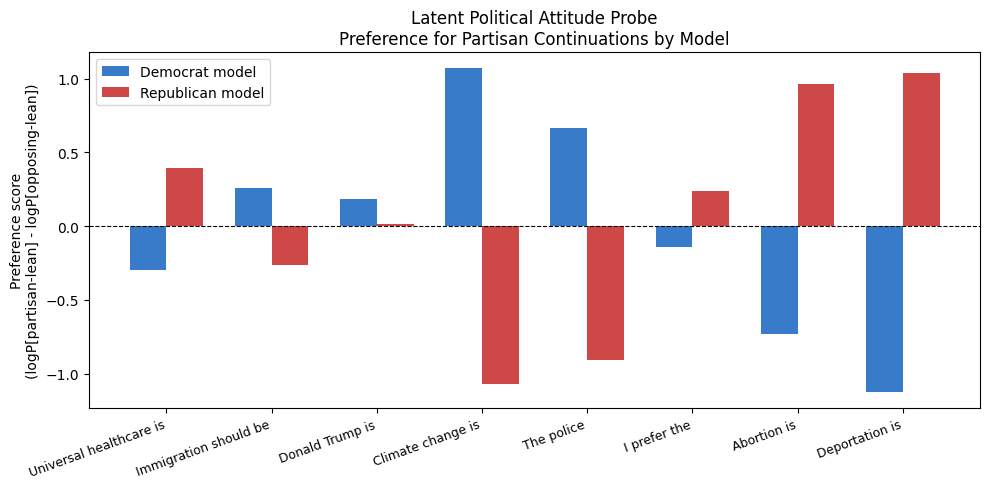

Saved: /tmp/preference_scores.png


In [29]:
# ── Visualise preference scores ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(logprob_df))
width = 0.35

bars1 = ax.bar(x - width/2, logprob_df['dem_model_pref_score'],
               width, label='Democrat model', color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2, logprob_df['rep_model_pref_score'],
               width, label='Republican model', color='#C62828', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([p[:28] + '…' if len(p) > 28 else p
                    for p in logprob_df['prompt']], rotation=20, ha='right', fontsize=9)
ax.set_ylabel("Preference score\n(logP[partisan-lean] - logP[opposing-lean])", fontsize=10)
ax.set_title("Latent Political Attitude Probe\nPreference for Partisan Continuations by Model",
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("/tmp/preference_scores.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: /tmp/preference_scores.png")


## Step 8: Representational Divergence via CKA

  Using the Centered Kernel Alignment (CKA) approach, we measure how differently the two fine-tuned models represent the same input texts at each transformer layer. Low cross-model CKA = the models have diverged in their internal representations, which would suggest they have encoded distinct linguistic/conceptual structures.


In [30]:
# ── CKA implementation ─────────────────────────
def linear_CKA(X: np.ndarray, Y: np.ndarray) -> float:
    """Linear CKA between two representation matrices (n_samples x n_features)."""
    def center(K):
        n = K.shape[0]
        H = np.eye(n) - np.ones((n, n)) / n
        return H @ K @ H

    K = X @ X.T
    L = Y @ Y.T
    return (np.trace(center(K) @ center(L)) /
            (np.linalg.norm(center(K), 'fro') * np.linalg.norm(center(L), 'fro') + 1e-10))


def extract_layer_activations(model, texts, tokenizer, max_length=64, n_samples=200):
    """Extract hidden-state activations from each transformer layer."""
    model.eval()
    base = model.base_model.model   # unwrap PEFT wrapper

    # Use a random subset for speed
    subset = texts[:n_samples]
    encodings = tokenizer(subset, truncation=True, padding='max_length',
                          max_length=max_length, return_tensors='pt')

    activations = []
    with torch.no_grad():
        outputs = base(
            input_ids=encodings['input_ids'].to(model.device),
            attention_mask=encodings['attention_mask'].to(model.device),
            output_hidden_states=True,
        )
        # outputs.hidden_states: tuple of (n_layers+1) tensors [batch, seq, hidden]
        for hs in outputs.hidden_states:
            # Mean-pool over sequence → shape [batch, hidden]
            act = hs.mean(dim=1).cpu().numpy()
            activations.append(act)
    return activations   # list of length n_layers+1


# ── Extract activations from both models on a shared probe set ───────────────────
PROBE_TEXTS = (dem_val_texts[:100] + rep_val_texts[:100])   # 200 texts, mixed

print("Extracting activations from Democrat model…")
act_dem = extract_layer_activations(model_dem, PROBE_TEXTS, tokenizer, n_samples=200)
print("Extracting activations from Republican model…")
act_rep = extract_layer_activations(model_rep, PROBE_TEXTS, tokenizer, n_samples=200)

print(f"\nLayers extracted: {len(act_dem)}")
print(f"Shape per layer: {act_dem[0].shape}")

Extracting activations from Democrat model…
Extracting activations from Republican model…

Layers extracted: 13
Shape per layer: (200, 768)


In [18]:
# ── Compute layer-wise CKA between the two partisan models ──────────────────
n_layers = min(len(act_dem), len(act_rep))
cka_scores = [linear_CKA(act_dem[i], act_rep[i]) for i in range(n_layers)]

print("Layer-wise CKA (Democrat model vs. Republican model):")
print(f"{'Layer':<8} {'CKA':>8}")
print("-" * 18)
for i, score in enumerate(cka_scores):
    bar = '█' * int(score * 20)
    print(f"L{i:<6d} {score:>8.4f}  {bar}")

print(f"\nMean CKA across layers: {np.mean(cka_scores):.4f}")
print("Interpretation: CKA=1.0 → identical representations; lower = more divergent")


Layer-wise CKA (Democrat model vs. Republican model):
Layer         CKA
------------------
L0        1.0000  ███████████████████
L1        0.9966  ███████████████████
L2        0.9979  ███████████████████
L3        0.9882  ███████████████████
L4        0.9939  ███████████████████
L5        0.9947  ███████████████████
L6        0.9941  ███████████████████
L7        0.9949  ███████████████████
L8        0.9949  ███████████████████
L9        0.9950  ███████████████████
L10       0.9958  ███████████████████
L11       0.9925  ███████████████████
L12       0.9549  ███████████████████

Mean CKA across layers: 0.9918
Interpretation: CKA=1.0 → identical representations; lower = more divergent


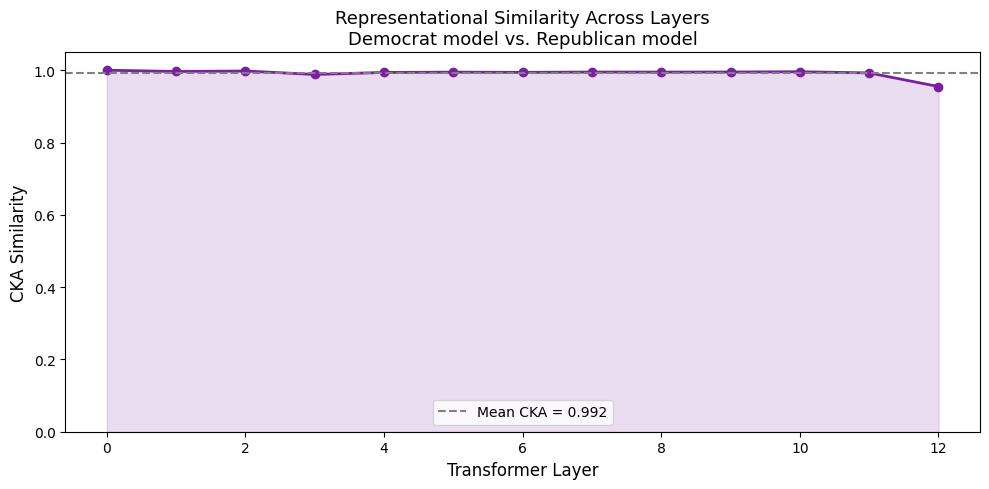

Lower layers (shared syntax) tend toward higher CKA.
Upper layers (semantic/pragmatic) may diverge more if political attitudes are encoded there.


In [19]:
# ── Plot layer-wise CKA divergence ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

layers = list(range(n_layers))
ax.plot(layers, cka_scores, marker='o', linewidth=2, color='#7B1FA2', markersize=6)
ax.fill_between(layers, cka_scores, alpha=0.15, color='#7B1FA2')
ax.axhline(np.mean(cka_scores), color='gray', linestyle='--', label=f'Mean CKA = {np.mean(cka_scores):.3f}')
ax.set_xlabel("Transformer Layer", fontsize=12)
ax.set_ylabel("CKA Similarity", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("Representational Similarity Across Layers\nDemocrat model vs. Republican model", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/cka_divergence.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Lower layers (shared syntax) tend toward higher CKA.")
print(f"Upper layers (semantic/pragmatic) may diverge more if political attitudes are encoded there.")


## Step 9: Summary & Discussion

### Findings

| Metric | What it tests | Expected if attitudes encoded |
|---|---|---|
| **Cross-partisan perplexity** | Does each model find the other group's text surprising? | Democrat model: higher PPL on Rep text (and vice versa) |
| **Preference scores** | Do models assign higher probability to their group's political framings? | Positive score for in-group framings |
| **Layer-wise CKA** | Have the two models' internal representations diverged? | CKA < 1.0, especially in upper (semantic) layers |
| **Qualitative text generation** | What world-view do completions express? | Partisan lexical/framing differences in completions |

### Methodological Notes

1. **Confounding**: Political affiliation is *inferred* from following behavior, not self-reported. TikTok descriptions mix hashtags, slang, and topical language — the model may be learning content-domain differences as much as attitude differences.

2. **Base model bias**: GPT-2 was pre-trained on web text with its own distributional biases. LoRA fine-tuning only adjusts a small fraction of parameters — residual pre-training biases persist and may distort results.

3. **Sampling balance**: We balanced the two corpora (Module 1 guidance), which removes class-imbalance confounds but also loses the natural asymmetry of the original data.

4. **Short texts**: TikTok descriptions are often just hashtags (#fyp, #viral). The political signal-to-noise ratio may be lower than longer-form political text.

### Research Extensions

- Fine-tune on political *content* only (filter out purely entertainment content)
- Use a political-domain pre-trained model (e.g., a news-domain model) as the base
- Apply DPO (Rafailov et al. 2023) as an alternative alignment method that directly learns preference differences between the two corpora
- Use probing classifiers (linear probes) on frozen activations to test if layer-specific representations are linearly separable by party
- Bootstrap the fine-tuning across multiple random subsamples (Module 1 bootstrap guidance) to estimate confidence intervals on CKA and perplexity differences


In [20]:
# ── Final summary printout ────────────────────────────────────────────────────
print("=" * 60)
print("PILOT STUDY RESULTS SUMMARY")
print("=" * 60)
print(f"\nCorpus size:")
print(f"  Democrat  : {len(df_dem):,} texts  ({len(dem_train_ds):,} train | {len(dem_val_ds):,} val)")
print(f"  Republican: {len(df_rep):,} texts  ({len(rep_train_ds):,} train | {len(rep_val_ds):,} val)")

print(f"\nParameter efficiency (Module 2, Task 2):")
trainable_lora = sum(p.numel() for p in model_dem.parameters() if p.requires_grad)
print(f"  Full fine-tuning params : {total_params:,}")
print(f"  LoRA trainable params   : {trainable_lora:,}  ({trainable_lora/total_params*100:.2f}%)")
print(f"  Reduction factor        : {total_params/trainable_lora:.0f}x")

print(f"\nRank experiment (Module 2, Task 3):")
for r, res in rank_results.items():
    print(f"  r={r:2d} | {res['trainable_params']:,} params | PPL={res.get('val_perplexity','N/A'):.2f}")

print(f"\nCross-partisan perplexity:")
print(f"  Democrat model  on Dem text: {dem_ppl:.2f}  | on Rep text: {dem_on_rep_ppl:.2f}")
print(f"  Republican model on Rep text: {rep_ppl:.2f}  | on Dem text: {rep_on_dem_ppl:.2f}")

print(f"\nRepresentational divergence (CKA):")
print(f"  Mean layer CKA (Dem vs. Rep model): {np.mean(cka_scores):.4f}")
print(f"  Min layer CKA : {min(cka_scores):.4f} (Layer {cka_scores.index(min(cka_scores))})")
print(f"  Max layer CKA : {max(cka_scores):.4f} (Layer {cka_scores.index(max(cka_scores))})")
print("=" * 60)


PILOT STUDY RESULTS SUMMARY

Corpus size:
  Democrat  : 15,000 texts  (13,500 train | 1,500 val)
  Republican: 15,000 texts  (13,500 train | 1,500 val)

Parameter efficiency (Module 2, Task 2):
  Full fine-tuning params : 124,439,808
  LoRA trainable params   : 294,912  (0.24%)
  Reduction factor        : 422x

Rank experiment (Module 2, Task 3):
  r= 4 | 147,456 params | PPL=85.43
  r= 8 | 294,912 params | PPL=84.97
  r=16 | 589,824 params | PPL=84.38

Cross-partisan perplexity:
  Democrat model  on Dem text: 46.26  | on Rep text: 47.45
  Republican model on Rep text: 45.40  | on Dem text: 49.13

Representational divergence (CKA):
  Mean layer CKA (Dem vs. Rep model): 0.9918
  Min layer CKA : 0.9549 (Layer 12)
  Max layer CKA : 1.0000 (Layer 0)
